# Install & Imorts

In [134]:
# install dataset
!pip install medmnist

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.5 MB/s eta 0:00:00


In [152]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from medmnist import BloodMNIST
import torchvision.transforms as transforms
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

# set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Sine Data

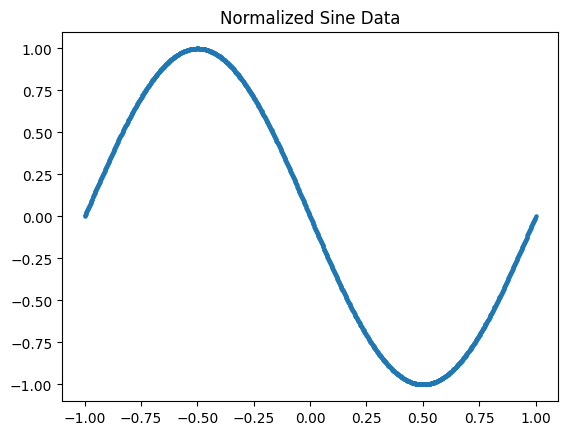

In [95]:
# generate sine data
def generate_sine(n=1000):
    x = np.linspace(0, 2*np.pi, n)
    y = np.sin(x)

    # normalize x to [-1,1]
    x = (x - np.pi) / np.pi

    data = np.stack([x, y], axis=1)
    return data

data = generate_sine()

# convert to tensor
real_data = torch.tensor(data, dtype=torch.float32)

# plot
plt.scatter(data[:,0], data[:,1], s=5)
plt.title("Normalized Sine Data")
plt.show()

In [96]:
# GENERATOR MODEL
class Generator(nn.Module):
    def __init__(self, noise_dim=5):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 128),   # noise → hidden
            nn.LeakyReLU(0.2),

            nn.Linear(128, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 2),            # output 2D point
            nn.Tanh()                    # range [-1,1]
        )

    def forward(self, z):
        return self.net(z)

In [97]:
# DISCRIMINATOR MODEL
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 128),           # input → hidden
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()                 # output probability
        )

    def forward(self, x):
        return self.net(x)

In [98]:
# INITIALIZE MODELS
noise_dim = 10

G = Generator(noise_dim)
D = Discriminator()

# loss function
criterion = nn.BCELoss()

# optimizers
g_opt = optim.Adam(G.parameters(), lr=0.0001)
d_opt = optim.Adam(D.parameters(), lr=0.0001)

# training settings
epochs = 9000
batch_size = 64

In [99]:
# TRAINING LOOP
for epoch in range(epochs):

    # train discriminator

    # pick real samples
    idx = np.random.randint(0, real_data.size(0), batch_size)
    real_batch = real_data[idx]

    # generate fake samples
    noise = torch.randn(batch_size, noise_dim)
    fake_batch = G(noise).detach()   # stop gradient

    # labels
    real_labels = torch.ones(batch_size, 1) * 0.9  # smoothing
    fake_labels = torch.zeros(batch_size, 1)

    # loss
    d_loss = criterion(D(real_batch), real_labels) + \
             criterion(D(fake_batch), fake_labels)

    # update D
    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()


    # train generator

    noise = torch.randn(batch_size, noise_dim)
    fake_data = G(noise)

    # generator tries to fool D
    g_loss = criterion(D(fake_data), torch.ones(batch_size, 1))

    # update G
    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    # print progress
    if epoch % 500 == 0:
        print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 1.3786 | G Loss: 0.7560
Epoch 500 | D Loss: 1.1358 | G Loss: 1.3418
Epoch 1000 | D Loss: 1.0522 | G Loss: 1.2168
Epoch 1500 | D Loss: 1.2721 | G Loss: 0.9156
Epoch 2000 | D Loss: 1.3615 | G Loss: 0.8342
Epoch 2500 | D Loss: 1.3518 | G Loss: 0.7860
Epoch 3000 | D Loss: 1.3685 | G Loss: 0.8068
Epoch 3500 | D Loss: 1.2776 | G Loss: 0.8533
Epoch 4000 | D Loss: 1.2802 | G Loss: 0.8990
Epoch 4500 | D Loss: 1.3397 | G Loss: 0.8459
Epoch 5000 | D Loss: 1.2983 | G Loss: 0.9530
Epoch 5500 | D Loss: 1.2915 | G Loss: 0.8466
Epoch 6000 | D Loss: 1.2185 | G Loss: 1.0450
Epoch 6500 | D Loss: 1.2511 | G Loss: 0.8856
Epoch 7000 | D Loss: 1.3114 | G Loss: 0.8471
Epoch 7500 | D Loss: 1.2605 | G Loss: 1.0722
Epoch 8000 | D Loss: 1.2855 | G Loss: 0.8836
Epoch 8500 | D Loss: 1.2635 | G Loss: 0.9780


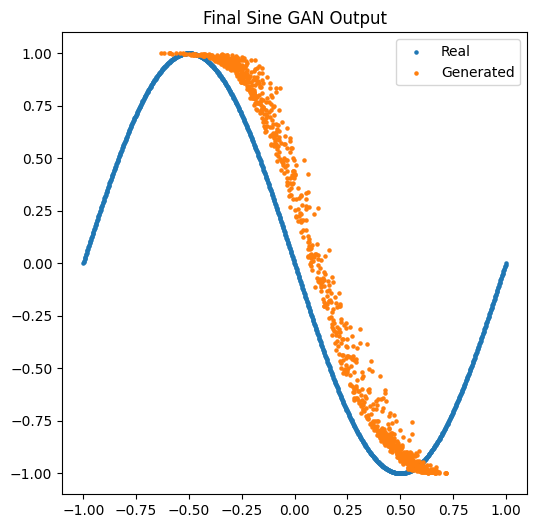

In [100]:
# VISUALIZE RESULT
noise = torch.randn(1000, noise_dim)
generated = G(noise).detach().numpy()

plt.figure(figsize=(6,6))

# real points
plt.scatter(data[:,0], data[:,1], s=5, label="Real")

# generated points
plt.scatter(generated[:,0], generated[:,1], s=5, label="Generated")

plt.legend()
plt.title("Final Sine GAN Output")
plt.show()

# Spiral Data

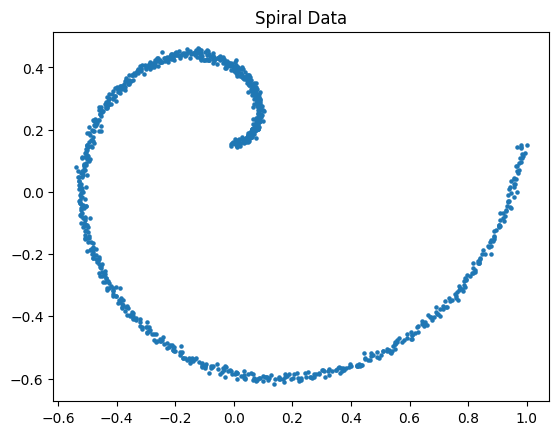

In [127]:
# create spiral data
def generate_spiral(n=1000):
    t = np.linspace(0, 2*np.pi, n)   # smaller spiral
    x = t * np.cos(t)
    y = t * np.sin(t)

    data = np.stack([x, y], axis=1)

    # add small noise
    data += 0.05 * np.random.randn(*data.shape)

    # center data
    data = data - np.mean(data, axis=0)

    # scale to [-1,1]
    data = data / np.max(np.abs(data))

    return data

data = generate_spiral()

# convert to tensor
real_data = torch.tensor(data, dtype=torch.float32)

# plot real data
plt.scatter(data[:,0], data[:,1], s=5)
plt.title("Spiral Data")
plt.show()

In [128]:
# generator model
class Generator(nn.Module):
    def __init__(self, noise_dim=10):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 128),  # noise input
            nn.BatchNorm1d(128),        # stabilize
            nn.LeakyReLU(0.2),

            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 2),           # output (x,y)
            nn.Tanh()                   # range [-1,1]
        )

    def forward(self, z):
        return self.net(z)

In [129]:
# discriminator model
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 128),   # input (x,y)
            nn.LeakyReLU(0.2),

            nn.Linear(128, 64),
            nn.LeakyReLU(0.2),

            nn.Linear(64, 32),
            nn.LeakyReLU(0.2),

            nn.Linear(32, 1),
            nn.Sigmoid()         # output real/fake
        )

    def forward(self, x):
        return self.net(x)

In [130]:
noise_dim = 10

G = Generator(noise_dim)
D = Discriminator()

criterion = nn.BCELoss()

# lower lr for stability
g_opt = optim.Adam(G.parameters(), lr=0.0001)
d_opt = optim.Adam(D.parameters(), lr=0.0001)

epochs = 15000
batch_size = 64

In [131]:
for epoch in range(epochs):

    # get real data
    idx = np.random.randint(0, real_data.size(0), batch_size)
    real_batch = real_data[idx]

    # generate fake data
    noise = torch.randn(batch_size, noise_dim)
    fake_batch = G(noise).detach()

    # labels
    real_labels = torch.ones(batch_size, 1) * 0.9  # smooth real
    fake_labels = torch.zeros(batch_size, 1)

    # train discriminator
    d_loss = criterion(D(real_batch), real_labels) + \
             criterion(D(fake_batch), fake_labels)

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    # train generator (multiple times)
    for _ in range(3):
        noise = torch.randn(batch_size, noise_dim)
        fake_data = G(noise)

        g_loss = criterion(D(fake_data), torch.ones(batch_size, 1))

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    # print progress
    if epoch % 2000 == 0:
        print(f"Epoch {epoch} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 0 | D: 1.3979 | G: 0.6504
Epoch 2000 | D: 1.3879 | G: 0.7921
Epoch 4000 | D: 1.3995 | G: 0.7491
Epoch 6000 | D: 1.3673 | G: 0.8146
Epoch 8000 | D: 1.3805 | G: 0.7993
Epoch 10000 | D: 1.3760 | G: 0.7969
Epoch 12000 | D: 1.3760 | G: 0.8013
Epoch 14000 | D: 1.3778 | G: 0.8045


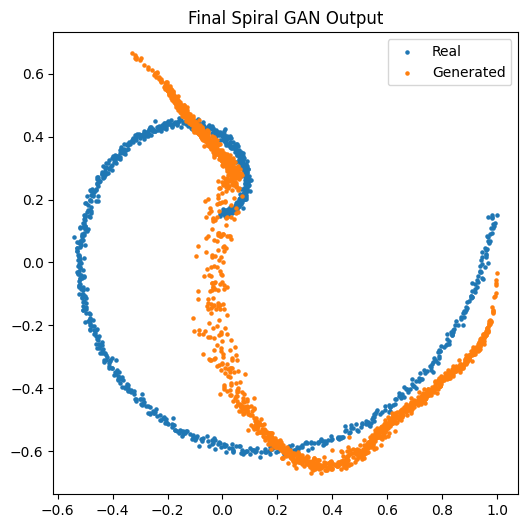

In [132]:
# generate points
noise = torch.randn(2000, noise_dim)
generated = G(noise).detach().numpy()

# plot
plt.figure(figsize=(6,6))

plt.scatter(data[:,0], data[:,1], s=5, label="Real")
plt.scatter(generated[:,0], generated[:,1], s=5, label="Generated")

plt.legend()
plt.title("Final Spiral GAN Output")
plt.show()

# BloodMNIST

In [138]:
# transform images to tensor and normalize
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1,1]
])

# load train dataset
train_dataset = BloodMNIST(split='train', transform=transform, download=True)

# dataloader
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

100%|██████████| 35.5M/35.5M [00:02<00:00, 14.7MB/s]


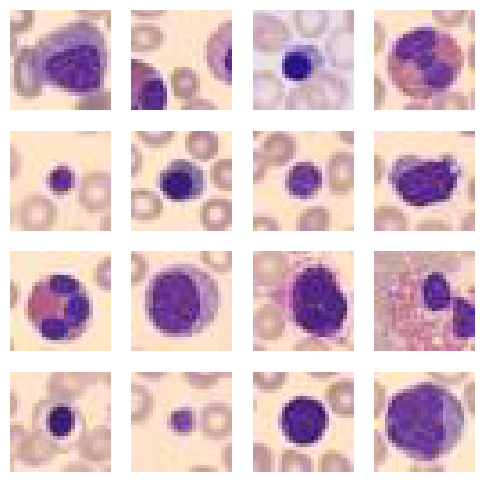

In [139]:
# show images
data_iter = iter(train_loader)
images, labels = next(data_iter)

plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(images[i].permute(1,2,0).numpy() * 0.5 + 0.5)
    plt.axis('off')

plt.show()

In [140]:
# generator
class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 128*7*7),  # expand noise
            nn.ReLU(),

            nn.Unflatten(1, (128, 7, 7)),   # reshape

            nn.ConvTranspose2d(128, 64, 4, 2, 1),  # upsample
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 3, 4, 2, 1),    # output image
            nn.Tanh()                              # [-1,1]
        )

    def forward(self, z):
        return self.net(z)

In [141]:
# discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # downsample
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()                # real/fake
        )

    def forward(self, x):
        return self.net(x)

In [142]:
noise_dim = 100

G = Generator(noise_dim)
D = Discriminator()

criterion = nn.BCELoss()

g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

epochs = 20

In [143]:
# train GAN
for epoch in range(epochs):

    for real_imgs, _ in train_loader:

        batch_size = real_imgs.size(0)

        # labels
        real_labels = torch.ones(batch_size, 1) * 0.9   # smooth real
        fake_labels = torch.zeros(batch_size, 1)


        # train discriminator

        noise = torch.randn(batch_size, noise_dim)
        fake_imgs = G(noise)

        d_real = D(real_imgs)
        d_fake = D(fake_imgs.detach())

        d_loss = criterion(d_real, real_labels) + \
                 criterion(d_fake, fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()


        # train generator
        noise = torch.randn(batch_size, noise_dim)
        fake_imgs = G(noise)

        g_loss = criterion(D(fake_imgs), torch.ones(batch_size, 1))

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    # print progress
    print(f"Epoch {epoch+1}/{epochs} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 1/20 | D: 0.3385 | G: 6.3917
Epoch 2/20 | D: 0.3469 | G: 5.3474
Epoch 3/20 | D: 0.3378 | G: 5.2848
Epoch 4/20 | D: 0.3299 | G: 6.5195
Epoch 5/20 | D: 0.3429 | G: 5.4325
Epoch 6/20 | D: 0.3475 | G: 5.1707
Epoch 7/20 | D: 0.3668 | G: 4.5532
Epoch 8/20 | D: 0.3934 | G: 5.3771
Epoch 9/20 | D: 0.3698 | G: 4.9164
Epoch 10/20 | D: 0.4379 | G: 3.0565
Epoch 11/20 | D: 0.3832 | G: 3.8821
Epoch 12/20 | D: 0.3750 | G: 5.0024
Epoch 13/20 | D: 0.3976 | G: 4.1114
Epoch 14/20 | D: 0.3883 | G: 3.8840
Epoch 15/20 | D: 0.3865 | G: 4.2145
Epoch 16/20 | D: 0.3840 | G: 3.1205
Epoch 17/20 | D: 0.3814 | G: 3.7437
Epoch 18/20 | D: 0.4776 | G: 2.4748
Epoch 19/20 | D: 0.3706 | G: 4.8082
Epoch 20/20 | D: 0.3949 | G: 3.1049


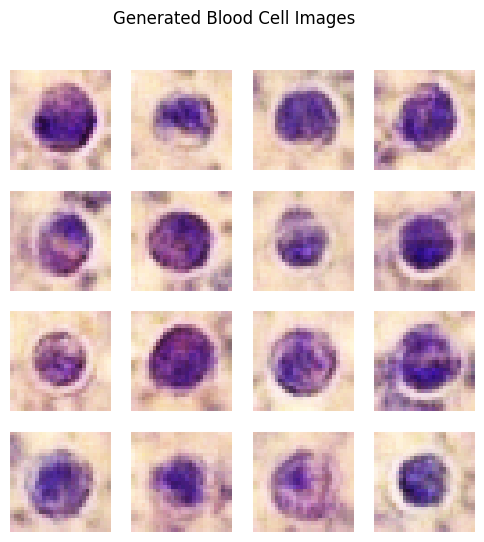

In [144]:
# generate fake images
noise = torch.randn(16, noise_dim)
fake_images = G(noise).detach()

# plot images
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)

    # convert [-1,1] → [0,1]
    img = fake_images[i].permute(1,2,0).numpy() * 0.5 + 0.5

    plt.imshow(img)
    plt.axis('off')

plt.suptitle("Generated Blood Cell Images")
plt.show()

# CICIDS 2017

In [153]:
# load dataset
import pandas as pd

file_path = "Wednesday-workingHours.pcap_ISCX.csv"

df = pd.read_csv(file_path)

# check data
print(df.shape)
df.head()

(231900, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80,38308,1,1,6,6,6,6,6.000000,0.000000,...,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
1,389,479,11,5,172,326,79,0,15.636364,31.449238,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
2,88,1095,10,6,3150,3150,1575,0,315.000000,632.561635,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
3,389,15206,17,12,3452,6660,1313,0,203.058823,425.778474,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN
4,88,1092,9,6,3150,3152,1575,0,350.000000,694.509719,...,32.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BENIGN


In [155]:
# print all columns clearly
for col in df.columns:
    print(f"'{col}'")

' Destination Port'
' Flow Duration'
' Total Fwd Packets'
' Total Backward Packets'
'Total Length of Fwd Packets'
' Total Length of Bwd Packets'
' Fwd Packet Length Max'
' Fwd Packet Length Min'
' Fwd Packet Length Mean'
' Fwd Packet Length Std'
'Bwd Packet Length Max'
' Bwd Packet Length Min'
' Bwd Packet Length Mean'
' Bwd Packet Length Std'
'Flow Bytes/s'
' Flow Packets/s'
' Flow IAT Mean'
' Flow IAT Std'
' Flow IAT Max'
' Flow IAT Min'
'Fwd IAT Total'
' Fwd IAT Mean'
' Fwd IAT Std'
' Fwd IAT Max'
' Fwd IAT Min'
'Bwd IAT Total'
' Bwd IAT Mean'
' Bwd IAT Std'
' Bwd IAT Max'
' Bwd IAT Min'
'Fwd PSH Flags'
' Bwd PSH Flags'
' Fwd URG Flags'
' Bwd URG Flags'
' Fwd Header Length'
' Bwd Header Length'
'Fwd Packets/s'
' Bwd Packets/s'
' Min Packet Length'
' Max Packet Length'
' Packet Length Mean'
' Packet Length Std'
' Packet Length Variance'
'FIN Flag Count'
' SYN Flag Count'
' RST Flag Count'
' PSH Flag Count'
' ACK Flag Count'
' URG Flag Count'
' CWE Flag Count'
' ECE Flag Count'
' Down

In [156]:
# remove spaces
df.columns = df.columns.str.strip()

# print again
print(df.columns)

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [157]:
# check unique labels
print(df['Label'].unique())
print(df['Label'].value_counts())

['BENIGN' 'DoS slowloris' 'DoS Slowhttptest' 'DoS Hulk' nan]
Label
DoS Hulk            148581
BENIGN               72023
DoS slowloris         5796
DoS Slowhttptest      5499
Name: count, dtype: int64


In [158]:
# keep BENIGN and DoS
df = df[df['Label'].str.contains('BENIGN|DoS', na=False)]

# convert to binary
df['Label'] = df['Label'].apply(lambda x: 0 if 'BENIGN' in x else 1)

print(df['Label'].value_counts())

# remove missing and inf
df = df.replace([np.inf, -np.inf], np.nan)
df = df.dropna()

/tmp/ipykernel_1152/4089607682.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Label'] = df['Label'].apply(lambda x: 0 if 'BENIGN' in x else 1)


Label
1    159876
0     72023
Name: count, dtype: int64


In [159]:
# keep numeric columns
df = df.select_dtypes(include=['float64', 'int64'])

# split features
X = df.drop('Label', axis=1)

# scale
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print("shape:", X_scaled.shape)

shape: (231249, 78)


In [160]:
data = torch.tensor(X_scaled, dtype=torch.float32)

In [162]:
class Generator(nn.Module):
    def __init__(self, noise_dim, output_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 256),
            nn.ReLU(),

            nn.Linear(256, output_dim),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [163]:
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [164]:
noise_dim = 20
input_dim = X_scaled.shape[1]

G = Generator(noise_dim, input_dim)
D = Discriminator(input_dim)

criterion = nn.BCELoss()

g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

epochs = 200
batch_size = 128

In [165]:
for epoch in range(epochs):

    # real batch
    idx = np.random.randint(0, data.size(0), batch_size)
    real_batch = data[idx]

    # fake batch
    noise = torch.randn(batch_size, noise_dim)
    fake_batch = G(noise).detach()

    real_labels = torch.ones(batch_size, 1) * 0.9
    fake_labels = torch.zeros(batch_size, 1)

    # train D
    d_loss = criterion(D(real_batch), real_labels) + \
             criterion(D(fake_batch), fake_labels)

    d_opt.zero_grad()
    d_loss.backward()
    d_opt.step()

    # train G
    noise = torch.randn(batch_size, noise_dim)
    fake_data = G(noise)

    g_loss = criterion(D(fake_data), torch.ones(batch_size, 1))

    g_opt.zero_grad()
    g_loss.backward()
    g_opt.step()

    if epoch % 50 == 0:
        print(f"Epoch {epoch} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 0 | D: 1.3954 | G: 0.6630
Epoch 50 | D: 1.3856 | G: 0.6569
Epoch 100 | D: 1.3437 | G: 1.0182
Epoch 150 | D: 1.1673 | G: 0.9767


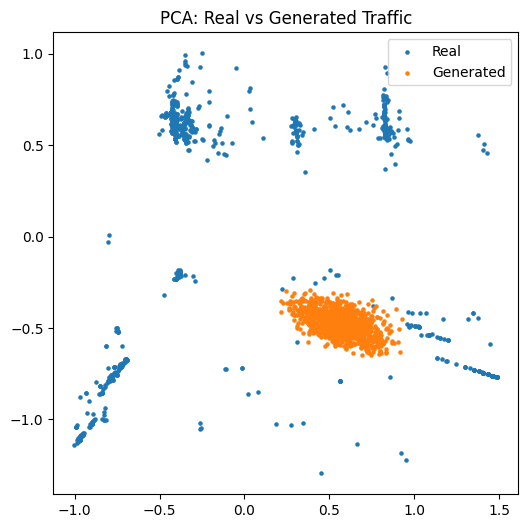

In [166]:
# sample real data
real_sample = data[:1000].numpy()

# generate fake data
noise = torch.randn(1000, noise_dim)
fake_sample = G(noise).detach().numpy()

# PCA
pca = PCA(n_components=2)

real_pca = pca.fit_transform(real_sample)
fake_pca = pca.transform(fake_sample)

# plot
plt.figure(figsize=(6,6))

plt.scatter(real_pca[:,0], real_pca[:,1], s=5, label="Real")
plt.scatter(fake_pca[:,0], fake_pca[:,1], s=5, label="Generated")

plt.legend()
plt.title("PCA: Real vs Generated Traffic")
plt.show()

# Pizza Dataset

In [168]:
# load pizza sketches
data = np.load("pizza.npy", allow_pickle=True)

print("shape:", data.shape)

shape: (130371, 784)


In [169]:
# reshape to 28x28 images
data = data.reshape(-1, 28, 28)

# normalize to [-1,1]
data = data / 255.0
data = data * 2 - 1

# add channel (grayscale)
data = data.reshape(-1, 1, 28, 28)

# convert to tensor
import torch
data = torch.tensor(data, dtype=torch.float32)

print(data.shape)

torch.Size([130371, 1, 28, 28])


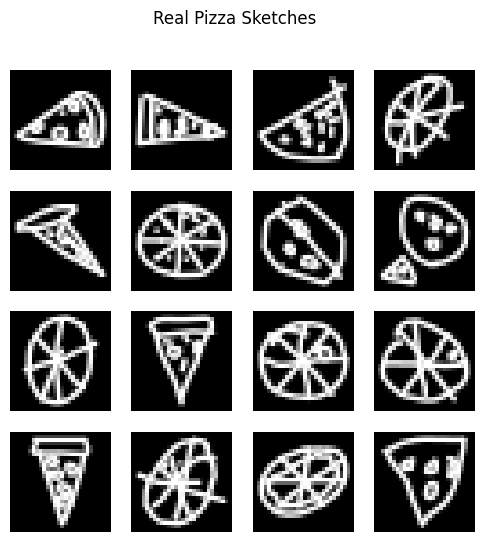

In [170]:
import matplotlib.pyplot as plt

# show samples
plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(data[i][0], cmap='gray')
    plt.axis('off')

plt.suptitle("Real Pizza Sketches")
plt.show()

In [171]:
# generator
import torch.nn as nn

class Generator(nn.Module):
    def __init__(self, noise_dim=100):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(noise_dim, 128*7*7),  # expand
            nn.ReLU(),

            nn.Unflatten(1, (128, 7, 7)),   # reshape

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 1, 4, 2, 1),  # 1 channel
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

In [172]:
# discriminator
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(1, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            nn.Flatten(),
            nn.Linear(128*7*7, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [173]:
import torch.optim as optim

noise_dim = 100

G = Generator(noise_dim)
D = Discriminator()

criterion = nn.BCELoss()

g_opt = optim.Adam(G.parameters(), lr=0.0002)
d_opt = optim.Adam(D.parameters(), lr=0.0002)

epochs = 20
batch_size = 64

In [174]:
from torch.utils.data import DataLoader, TensorDataset

loader = DataLoader(TensorDataset(data), batch_size=batch_size, shuffle=True)

for epoch in range(epochs):

    for real_imgs, in loader:

        batch_size = real_imgs.size(0)

        real_labels = torch.ones(batch_size, 1) * 0.9
        fake_labels = torch.zeros(batch_size, 1)

        # train D
        noise = torch.randn(batch_size, noise_dim)
        fake_imgs = G(noise)

        d_loss = criterion(D(real_imgs), real_labels) + \
                 criterion(D(fake_imgs.detach()), fake_labels)

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # train G
        noise = torch.randn(batch_size, noise_dim)
        fake_imgs = G(noise)

        g_loss = criterion(D(fake_imgs), torch.ones(batch_size, 1))

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

    print(f"Epoch {epoch+1}/{epochs} | D: {d_loss.item():.4f} | G: {g_loss.item():.4f}")

Epoch 1/20 | D: 0.5000 | G: 3.5286
Epoch 2/20 | D: 0.3785 | G: 5.2717
Epoch 3/20 | D: 0.3757 | G: 7.0650
Epoch 4/20 | D: 0.3921 | G: 4.3879
Epoch 5/20 | D: 0.4615 | G: 4.8515
Epoch 6/20 | D: 0.3745 | G: 4.6165
Epoch 7/20 | D: 0.3736 | G: 6.0553
Epoch 8/20 | D: 0.5321 | G: 6.1491
Epoch 9/20 | D: 0.6242 | G: 4.7952
Epoch 10/20 | D: 0.4115 | G: 6.9464
Epoch 11/20 | D: 0.3529 | G: 3.8581
Epoch 12/20 | D: 0.5020 | G: 4.6744
Epoch 13/20 | D: 0.4991 | G: 5.2917
Epoch 14/20 | D: 0.3667 | G: 4.5377
Epoch 15/20 | D: 0.7265 | G: 5.6391
Epoch 16/20 | D: 0.3985 | G: 3.9295
Epoch 17/20 | D: 0.9288 | G: 4.8807
Epoch 18/20 | D: 0.5231 | G: 4.7266
Epoch 19/20 | D: 0.3723 | G: 4.4454
Epoch 20/20 | D: 0.4983 | G: 6.7447


In [175]:
# generate fake sketches
noise = torch.randn(16, noise_dim)
fake_imgs = G(noise).detach()

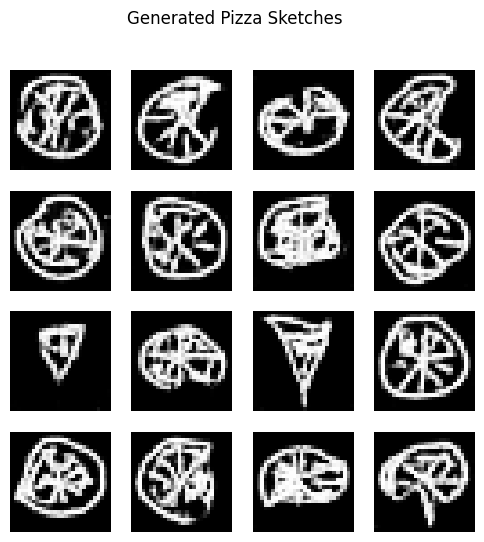

In [176]:
# plot generated sketches
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

for i in range(16):
    plt.subplot(4,4,i+1)

    # convert [-1,1] → [0,1]
    img = fake_imgs[i][0].numpy() * 0.5 + 0.5

    plt.imshow(img, cmap='gray')
    plt.axis('off')

plt.suptitle("Generated Pizza Sketches")
plt.show()

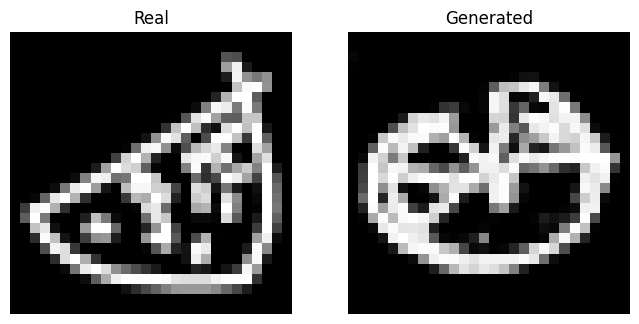

In [185]:
# compare real and fake
plt.figure(figsize=(8,4))

# real
plt.subplot(1,2,1)
plt.imshow(data[2][0], cmap='gray')
plt.title("Real")
plt.axis('off')

# fake
plt.subplot(1,2,2)
plt.imshow(fake_imgs[2][0].numpy()*0.5+0.5, cmap='gray')
plt.title("Generated")
plt.axis('off')

plt.show()